# Data Processing

## Basic and Encoding

In [ ]:
import pandas as pd
df_sample = pd.DataFrame({
    'age': [25, 30, 35, 40, 45],
    'salary': [30000, 45000, 50000, 60000, 70000],
    'city': ['New York', 'London', 'Paris', 'New York', 'London'],
    'education': ['High School', 'Bachelor', 'Master', 'PhD', 'Bachelor'],
    'purchased': ['No', 'Yes', 'Yes', 'Yes', 'No']
})

df_sample

,age,salary,city,education,purchased
0,25,30000,New York,High School,No
1,30,45000,London,Bachelor,Yes
2,35,50000,Paris,Master,Yes
3,40,60000,New York,PhD,Yes
4,45,70000,London,Bachelor,No


In [ ]:
print("="*100)
print("Step 1 : Understanding the Data")
print("="*100)

print("\n\t\t 1. Dataset Info\n")
print(df_sample.info())

print("\n\t\t 2. Dataset Description\n")
print(df_sample.describe())

print("\n\t\t 3. Check missing values\n")
print(df_sample.isnull().sum())

print("\n\t\t 4. Check duplicate values\n")
print(df_sample.duplicated().sum())

print("\n\t\t 5. Check unique values\n")
print(df_sample.nunique())

print("\n\t\t 6. Check Data Types\n")
print(df_sample.dtypes)





Step 1 : Understanding the Data

		 1. Dataset Info

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        5 non-null      int64 
 1   salary     5 non-null      int64 
 2   city       5 non-null      object
 3   education  5 non-null      object
 4   purchased  5 non-null      object
dtypes: int64(2), object(3)
memory usage: 332.0+ bytes
None

		 2. Dataset Description

             age        salary
count   5.000000      5.000000
mean   35.000000  51000.000000
std     7.905694  15165.750888
min    25.000000  30000.000000
25%    30.000000  45000.000000
50%    35.000000  50000.000000
75%    40.000000  60000.000000
max    45.000000  70000.000000

		 3. Check missing values

age          0
salary       0
city         0
education    0
purchased    0
dtype: int64

		 4. Check duplicate values

0

		 5. Check unique values

age          5
salary       5

In [ ]:
print("="*100)
print("Step 2 : Data Preprocessing")
print("="*100)

print("\n\t\t 1. LABEL ENCODING\n")

print(df_sample)


print("\n\t\t 1.1 For orders in columns\n")
print(df_sample['education'].unique())

print("\n\t\t Before Encoding\n")
print(df_sample)

print("\n\t\t After Encoding\n")
education_mapping = {'High School': 0, 'Bachelor': 1, 'Master': 2, 'PhD': 3}
df_sample['education_encoded'] = df_sample['education'].map(education_mapping)
df_sample = df_sample.drop('education', axis=1)
print(df_sample)


print("\n\t\t 1.2 For Non-orders in columns\n")
print(df_sample['city'].unique())

print("\n\t\t Before Encoding\n")
print(df_sample)

print("\n\t\t After Encoding\n")
city_encoded = pd.get_dummies(df_sample['city'],prefix="city").astype(int)
df_sample = pd.concat([df_sample,city_encoded],axis=1)
df_sample = df_sample.drop('city', axis=1)
df_sample['purchased'] = df_sample['purchased'].map({'No': 0, 'Yes': 1})
print(df_sample)



Step 2 : Data Preprocessing

		 1. LABEL ENCODING

   age  salary      city    education purchased
0   25   30000  New York  High School        No
1   30   45000    London     Bachelor       Yes
2   35   50000     Paris       Master       Yes
3   40   60000  New York          PhD       Yes
4   45   70000    London     Bachelor        No

		 1.1 For orders in columns

['High School' 'Bachelor' 'Master' 'PhD']

		 Before Encoding

   age  salary      city    education purchased
0   25   30000  New York  High School        No
1   30   45000    London     Bachelor       Yes
2   35   50000     Paris       Master       Yes
3   40   60000  New York          PhD       Yes
4   45   70000    London     Bachelor        No

		 After Encoding

   age  salary      city purchased  education_encoded
0   25   30000  New York        No                  0
1   30   45000    London       Yes                  1
2   35   50000     Paris       Yes                  2
3   40   60000  New York       Yes         

In [ ]:
df_sample

,age,salary,purchased,education_encoded,city_London,city_New York,city_Paris
0,25,30000,0,0,0,1,0
1,30,45000,1,1,1,0,0
2,35,50000,1,2,0,0,1
3,40,60000,1,3,0,1,0
4,45,70000,0,1,1,0,0


##STANDARDIZATION and visual


STANDARDIZATION & NORMALIZATION

📊 Original Data (notice different scales):
   age  salary  purchased  education_encoded  city_London  city_New York  \
0   25   30000          0                  0            0              1   
1   30   45000          1                  1            1              0   
2   35   50000          1                  2            0              0   
3   40   60000          1                  3            0              1   
4   45   70000          0                  1            1              0   

   city_Paris  
0           0  
1           0  
2           1  
3           0  
4           0  

Statistics:
             age        salary  purchased  education_encoded  city_London  \
count   5.000000      5.000000   5.000000           5.000000     5.000000   
mean   35.000000  51000.000000   0.600000           1.400000     0.400000   
std     7.905694  15165.750888   0.547723           1.140175     0.547723   
min    25.000000  30000.000000   0.000000        

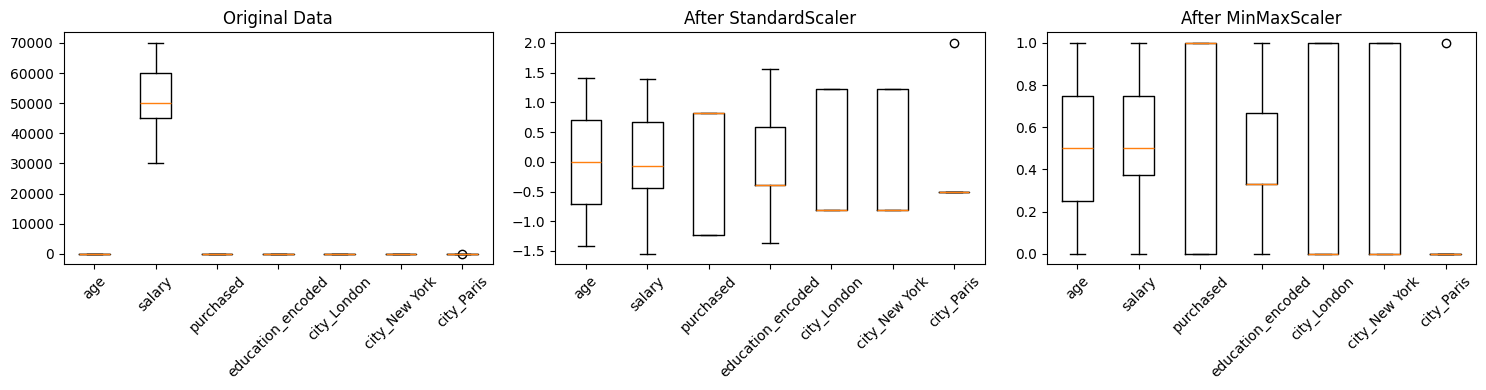

In [ ]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

print("\n" + "="*60)
print("STANDARDIZATION & NORMALIZATION")
print("="*60)
scaling_data = df_sample
print("\n📊 Original Data (notice different scales):")
print(scaling_data)
print("\nStatistics:")
print(scaling_data.describe())

scaler_standard = StandardScaler()
data_standardized = scaler_standard.fit_transform(scaling_data)
df_standardized = pd.DataFrame(data_standardized, columns=scaling_data.columns)

print("\n ----------------- After StandardScaler:")
print(df_standardized)
print("\n ----------------- New Statistics (mean ≈ 0, std ≈ 1):")
print(df_standardized.describe())


scaler_minmax = MinMaxScaler()
data_normalized = scaler_minmax.fit_transform(scaling_data)
df_normalized = pd.DataFrame(data_normalized, columns=scaling_data.columns)

print("\n ************ After MinMaxScaler:")
print(df_normalized)
print("\n ************ New Statistics (min=0, max=1):")
print(df_normalized.describe())


fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].boxplot(scaling_data.values)
axes[0].set_title('Original Data')
axes[0].set_xticklabels(scaling_data.columns, rotation=45)

axes[1].boxplot(df_standardized.values)
axes[1].set_title('After StandardScaler')
axes[1].set_xticklabels(scaling_data.columns, rotation=45)

axes[2].boxplot(df_normalized.values)
axes[2].set_title('After MinMaxScaler')
axes[2].set_xticklabels(scaling_data.columns, rotation=45)

plt.tight_layout()
plt.show()


# ML - Supervised

In [ ]:
import pandas
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression,LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, classification_report, confusion_matrix
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier



In [ ]:
from sklearn.datasets import load_diabetes, load_iris

## Regression

In [ ]:
diabetes = load_diabetes()
df_diabetes = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
df_diabetes['target'] = diabetes.target

df_regression = df_diabetes
df_regression

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0
...,...,...,...,...,...,...,...,...,...,...,...
437,0.041708,0.050680,0.019662,0.059744,-0.005697,-0.002566,-0.028674,-0.002592,0.031193,0.007207,178.0
438,-0.005515,0.050680,-0.015906,-0.067642,0.049341,0.079165,-0.028674,0.034309,-0.018114,0.044485,104.0
439,0.041708,0.050680,-0.015906,0.017293,-0.037344,-0.013840,-0.024993,-0.011080,-0.046883,0.015491,132.0
440,-0.045472,-0.044642,0.039062,0.001215,0.016318,0.015283,-0.028674,0.026560,0.044529,-0.025930,220.0


In [ ]:
print("\n📊 REGRESSION DATASET (Diabetes):")

print(f"\nShape: {df_regression.shape}")


print("\n" + "="*60)
print("STEP 1: UNDERSTANDING THE DATA")
print("="*60)

# Basic information about regression dataset
print("\n1️⃣ Dataset Info:")
print(df_regression.info())

print("\n2️⃣ Statistical Summary:")
print(df_regression.describe())

print("\n3️⃣ Check Missing Values:")
print(df_regression.isnull().sum())

print("\n4️⃣ Check Data Types:")
print(df_regression.dtypes)


📊 REGRESSION DATASET (Diabetes):

Shape: (442, 11)

STEP 1: UNDERSTANDING THE DATA

1️⃣ Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  target  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB
None

2️⃣ Statistical Summary:
                age           sex           bmi            bp            s1  \
count  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02   
mean  -2.511817e-19  1.230790e-17 -2.245564e-16 -4.797570e-17 -1.381499e-17   
s


EXPLORATORY DATA ANALYSIS (EDA)

📊 Working with Regression Dataset


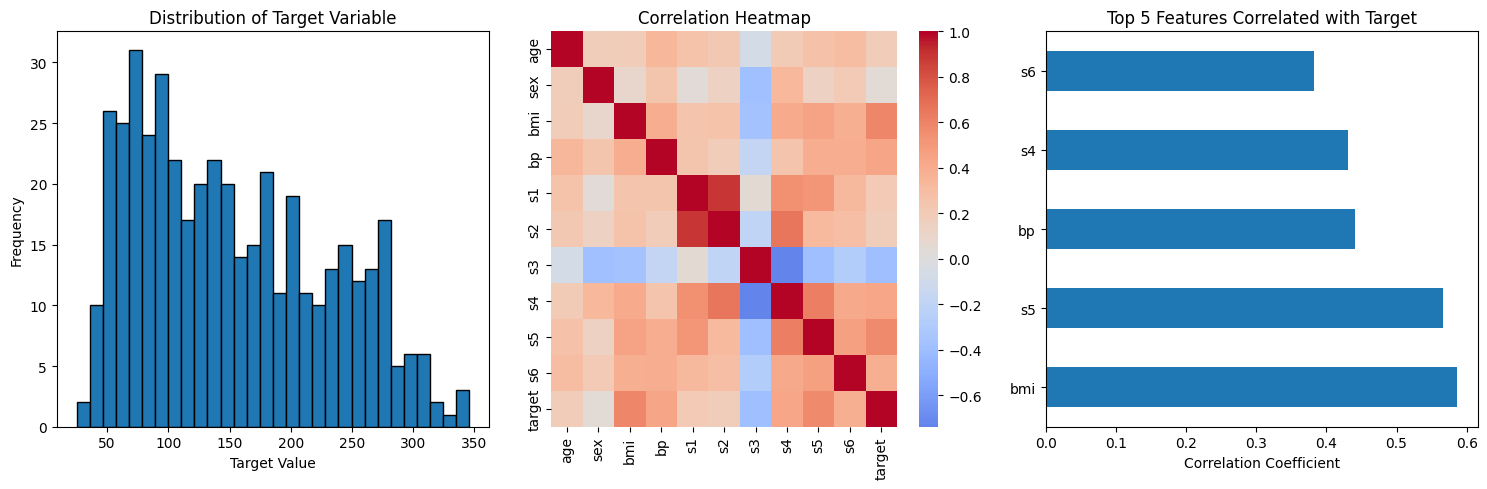


🔍 Key Insights from EDA:
✓ Dataset has 442 samples and 11 features
✓ Target variable range: 25.00 to 346.00

✓ Top 5 correlated features with target:
bmi    0.586450
s5     0.565883
bp     0.441482
s4     0.430453
s6     0.382483
Name: target, dtype: float64


In [ ]:
print("\n" + "="*60)
print("EXPLORATORY DATA ANALYSIS (EDA)")
print("="*60)

# Use regression dataset for EDA
print("\n📊 Working with Regression Dataset")

# 1. Distribution of target variable
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.hist(df_regression['target'], bins=30, edgecolor='black')
plt.title('Distribution of Target Variable')
plt.xlabel('Target Value')
plt.ylabel('Frequency')


plt.subplot(1, 3, 2)
correlation_matrix = df_regression.corr()
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')


plt.subplot(1, 3, 3)
target_corr = correlation_matrix['target'].sort_values(ascending=False)[1:6]
target_corr.plot(kind='barh')
plt.title('Top 5 Features Correlated with Target')
plt.xlabel('Correlation Coefficient')


plt.tight_layout()
plt.show()


print("\n🔍 Key Insights from EDA:")
print(f"✓ Dataset has {df_regression.shape[0]} samples and {df_regression.shape[1]} features")
print(f"✓ Target variable range: {df_regression['target'].min():.2f} to {df_regression['target'].max():.2f}")
print("\n✓ Top 5 correlated features with target:")
print(target_corr)

In [ ]:
print("\n" + "="*60)
print("REGRESSION MODELS")
print("="*60)

# Prepare data
X_reg = df_regression.drop('target', axis=1)
y_reg = df_regression['target']

# Split data
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

print(f"\n📊 Data Split:")
print(f"Training set: {X_train_reg.shape[0]} samples")
print(f"Testing set: {X_test_reg.shape[0]} samples")



REGRESSION MODELS

📊 Data Split:
Training set: 353 samples
Testing set: 89 samples


In [ ]:
print("\n" + "-"*60)
print("MODEL 1: LINEAR REGRESSION")
print("-"*60)
print("✓ Simple and interpretable")
print("✓ Assumes linear relationship")
print("✓ Good for baseline model")
# scaler_reg = StandardScaler()
# X_train_reg_scaled = scaler_reg.fit_transform(X_train_reg)
# X_test_reg_scaled = scaler_reg.transform(X_test_reg)

lr = LinearRegression()
lr.fit(X_train_reg, y_train_reg)
pred = lr.predict(X_test_reg)

mse_lr = mean_squared_error(y_test_reg, pred)
r2_lr = r2_score(y_test_reg, pred)

print(f"\n📈 Results:")
print(f"Mean Squared Error: {mse_lr:.2f}")
print(f"R² Score: {r2_lr:.4f}")


print("\n\nMODEL 2: DECISION TREE REGRESSOR")
print("-"*60)
print("✓ Handles non-linear relationships")
print("✓ No need for scaling")
print("✓ Can overfit if not controlled")

dt = DecisionTreeRegressor(random_state=42, max_depth=5)
dt.fit(X_train_reg, y_train_reg)  # No scaling needed!
y_pred_dt = dt.predict(X_test_reg)

mse_dt = mean_squared_error(y_test_reg, y_pred_dt)
r2_dt = r2_score(y_test_reg, y_pred_dt)

print(f"\n📈 Results:")
print(f"Mean Squared Error: {mse_dt:.2f}")
print(f"R² Score: {r2_dt:.4f}")


print("\n" + "-"*60)
print("MODEL 3: RANDOM FOREST REGRESSOR")
print("-"*60)
print("✓ Ensemble of decision trees")
print("✓ Less prone to overfitting")
print("✓ Usually gives best results")
print("✓ No scaling needed")

rf = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=5)
rf.fit(X_train_reg, y_train_reg)
y_pred_rf = rf.predict(X_test_reg)

mse_rf = mean_squared_error(y_test_reg, y_pred_rf)
r2_rf = r2_score(y_test_reg, y_pred_rf)

print(f"\n📈 Results:")
print(f"Mean Squared Error: {mse_rf:.2f}")
print(f"R² Score: {r2_rf:.4f}")


------------------------------------------------------------
MODEL 1: LINEAR REGRESSION
------------------------------------------------------------
✓ Simple and interpretable
✓ Assumes linear relationship
✓ Good for baseline model

📈 Results:
Mean Squared Error: 2900.19
R² Score: 0.4526


MODEL 2: DECISION TREE REGRESSOR
------------------------------------------------------------
✓ Handles non-linear relationships
✓ No need for scaling
✓ Can overfit if not controlled

📈 Results:
Mean Squared Error: 3526.02
R² Score: 0.3345

------------------------------------------------------------
MODEL 3: RANDOM FOREST REGRESSOR
------------------------------------------------------------
✓ Ensemble of decision trees
✓ Less prone to overfitting
✓ Usually gives best results
✓ No scaling needed

📈 Results:
Mean Squared Error: 2881.58
R² Score: 0.4561



🏆 MODEL COMPARISON - REGRESSION
               Model          MSE  R² Score
0  Linear Regression  2900.193628  0.452603
1      Decision Tree  3526.015512  0.334482
2      Random Forest  2881.579106  0.456116


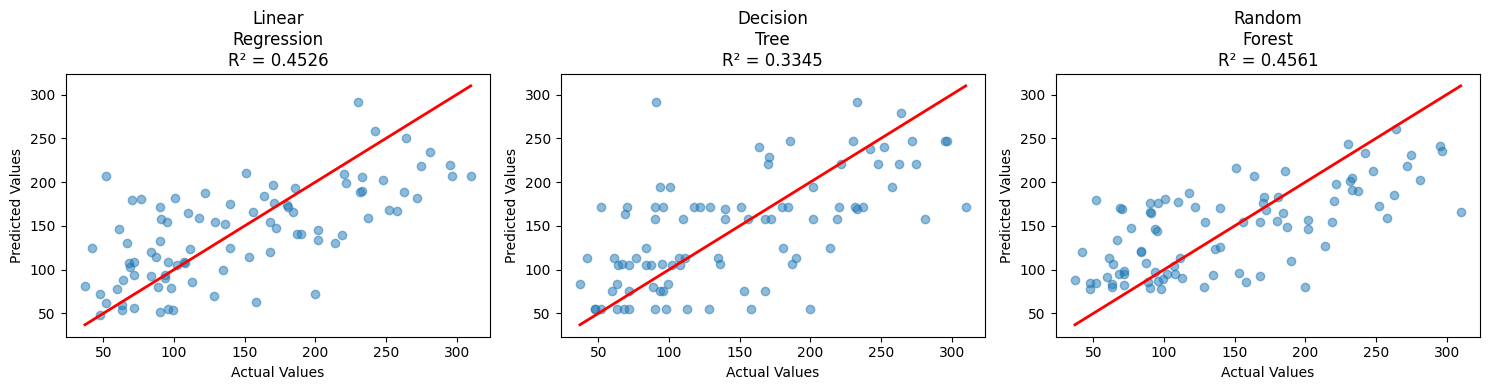

In [ ]:
print("\n" + "="*60)
print("🏆 MODEL COMPARISON - REGRESSION")
print("="*60)

comparison_reg = pd.DataFrame({
    'Model': ['Linear Regression', 'Decision Tree', 'Random Forest'],
    'MSE': [mse_lr, mse_dt, mse_rf],
    'R² Score': [r2_lr, r2_dt, r2_rf]
})
print(comparison_reg)

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

models = ['Linear\nRegression', 'Decision\nTree', 'Random\nForest']
r2_scores = [r2_lr, r2_dt, r2_rf]

for i, (ax, model, r2, y_pred) in enumerate(zip(axes, models, r2_scores,
                                                   [pred, y_pred_dt, y_pred_rf])):
    ax.scatter(y_test_reg, y_pred, alpha=0.5)
    ax.plot([y_test_reg.min(), y_test_reg.max()],
            [y_test_reg.min(), y_test_reg.max()], 'r', lw=2)
    ax.set_xlabel('Actual Values')
    ax.set_ylabel('Predicted Values')
    ax.set_title(f'{model}\nR² = {r2:.4f}')

plt.tight_layout()
plt.show()

## Classification

In [ ]:
iris = load_iris()
df_classification = pd.DataFrame(iris.data, columns=iris.feature_names)
df_classification['species'] = iris.target
print("\n📊 CLASSIFICATION DATASET (Iris):")
print(df_classification.head())
print(f"\nShape: {df_classification.shape}")


print("\n" + "="*60)
print("STEP 1: UNDERSTANDING THE DATA")
print("="*60)

# Basic information about regression dataset
print("\n1️⃣ Dataset Info:")
print(df_classification.info())

print("\n2️⃣ Statistical Summary:")
print(df_classification.describe())

print("\n3️⃣ Check Missing Values:")
print(df_classification.isnull().sum())

print("\n4️⃣ Check Data Types:")
print(df_classification.dtypes)



📊 CLASSIFICATION DATASET (Iris):
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   species  
0        0  
1        0  
2        0  
3        0  
4        0  

Shape: (150, 5)

STEP 1: UNDERSTANDING THE DATA

1️⃣ Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 


EXPLORATORY DATA ANALYSIS (EDA)

📊 Working with Regression Dataset


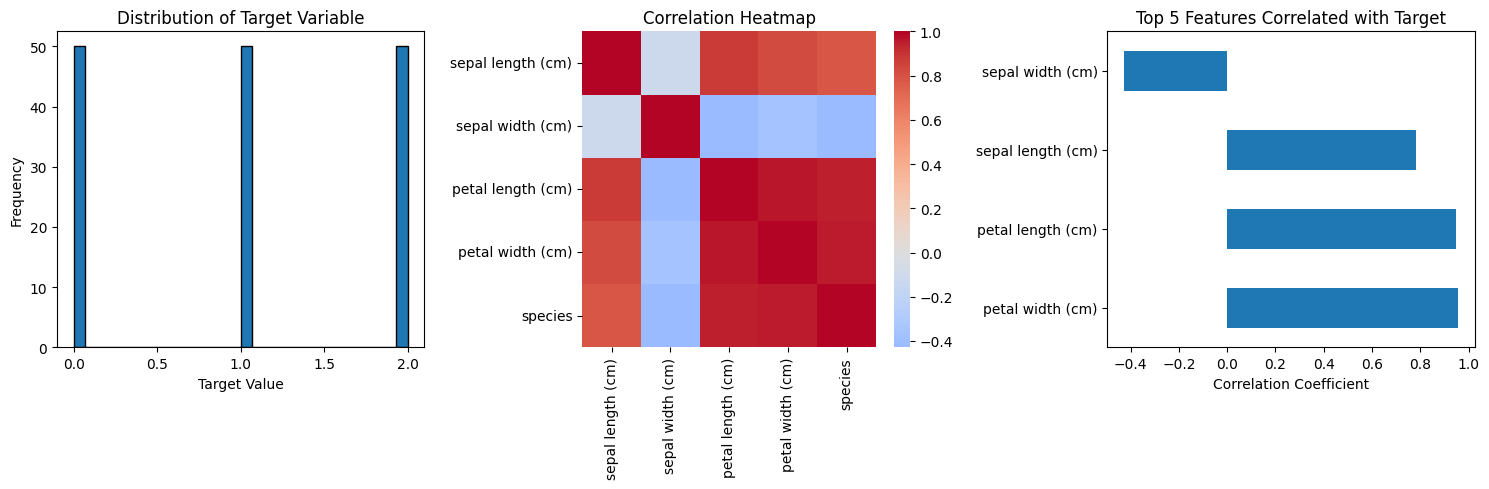


🔍 Key Insights from EDA:
✓ Dataset has 150 samples and 5 features
✓ Target variable range: 0.00 to 2.00

✓ Top 5 correlated features with target:
petal width (cm)     0.956547
petal length (cm)    0.949035
sepal length (cm)    0.782561
sepal width (cm)    -0.426658
Name: species, dtype: float64


In [ ]:
print("\n" + "="*60)
print("EXPLORATORY DATA ANALYSIS (EDA)")
print("="*60)

# Use regression dataset for EDA
print("\n📊 Working with Regression Dataset")

# 1. Distribution of target variable
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.hist(df_classification['species'], bins=30, edgecolor='black')
plt.title('Distribution of Target Variable')
plt.xlabel('Target Value')
plt.ylabel('Frequency')


plt.subplot(1, 3, 2)
correlation_matrix = df_classification.corr()
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')


plt.subplot(1, 3, 3)
target_corr = correlation_matrix['species'].sort_values(ascending=False)[1:6]
target_corr.plot(kind='barh')
plt.title('Top 5 Features Correlated with Target')
plt.xlabel('Correlation Coefficient')


plt.tight_layout()
plt.show()


print("\n🔍 Key Insights from EDA:")
print(f"✓ Dataset has {df_classification.shape[0]} samples and {df_classification.shape[1]} features")
print(f"✓ Target variable range: {df_classification['species'].min():.2f} to {df_classification['species'].max():.2f}")
print("\n✓ Top 5 correlated features with target:")
print(target_corr)

In [ ]:
print("\n" + "="*60)
print("STEP 6: CLASSIFICATION MODELS")
print("="*60)

# Prepare classification data
X_clf = df_classification.drop('species', axis=1)
y_clf = df_classification['species']

# Split data
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

print(f"\n📊 Data Split:")
print(f"Training set: {X_train_clf.shape[0]} samples")
print(f"Testing set: {X_test_clf.shape[0]} samples")
print(f"\nClass distribution in training:")
print(y_train_clf.value_counts())

# Scale data
scaler_clf = StandardScaler()
X_train_clf_scaled = scaler_clf.fit_transform(X_train_clf)
X_test_clf_scaled = scaler_clf.transform(X_test_clf)

# MODEL 1: Logistic Regression
print("\n" + "-"*60)
print("MODEL 1: LOGISTIC REGRESSION")
print("-"*60)
print("✓ Despite name, used for classification")
print("✓ Probabilistic predictions")
print("✓ Fast and interpretable")

log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train_clf_scaled, y_train_clf)
y_pred_log = log_reg.predict(X_test_clf_scaled)

acc_log = accuracy_score(y_test_clf, y_pred_log)

print(f"\n📈 Results:")
print(f"Accuracy: {acc_log:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_clf, y_pred_log))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test_clf, y_pred_log))

# MODEL 2: Decision Tree Classifier
print("\n" + "-"*60)
print("MODEL 2: DECISION TREE CLASSIFIER")
print("-"*60)
print("✓ Easy to visualize and interpret")
print("✓ No scaling needed")
print("✓ Handles non-linear boundaries")

dt_clf = DecisionTreeClassifier(random_state=42, max_depth=4)
dt_clf.fit(X_train_clf, y_train_clf)
y_pred_dt_clf = dt_clf.predict(X_test_clf)

acc_dt = accuracy_score(y_test_clf, y_pred_dt_clf)

print(f"\n📈 Results:")
print(f"Accuracy: {acc_dt:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_clf, y_pred_dt_clf))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test_clf, y_pred_dt_clf))

# MODEL 3: Random Forest Classifier
print("\n" + "-"*60)
print("MODEL 3: RANDOM FOREST CLASSIFIER")
print("-"*60)
print("✓ Ensemble method - very powerful")
print("✓ Robust and accurate")
print("✓ Provides feature importance")

rf_clf = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=4)
rf_clf.fit(X_train_clf, y_train_clf)
y_pred_rf_clf = rf_clf.predict(X_test_clf)

acc_rf = accuracy_score(y_test_clf, y_pred_rf_clf)

print(f"\n📈 Results:")
print(f"Accuracy: {acc_rf:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_clf, y_pred_rf_clf))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test_clf, y_pred_rf_clf))







STEP 6: CLASSIFICATION MODELS

📊 Data Split:
Training set: 120 samples
Testing set: 30 samples

Class distribution in training:
species
0    40
2    40
1    40
Name: count, dtype: int64

------------------------------------------------------------
MODEL 1: LOGISTIC REGRESSION
------------------------------------------------------------
✓ Despite name, used for classification
✓ Probabilistic predictions
✓ Fast and interpretable

📈 Results:
Accuracy: 0.9333

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.90      0.90      0.90        10
           2       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30


Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]

------------------------------------------------------------
MODEL 2: DECISIO

In [ ]:
rf_clf.feature_importances_

array([0.11564462, 0.01075376, 0.43774477, 0.43585686])

In [ ]:
#Feature Importance
print("\n🔍 Feature Importance (from Random Forest):")
feature_importance = pd.DataFrame({
    'Feature': X_clf.columns,
    'Importance': rf_clf.feature_importances_
}).sort_values('Importance', ascending=False)
print(feature_importance)

# Compare all classification models
print("\n" + "="*60)
print("🏆 MODEL COMPARISON - CLASSIFICATION")
print("="*60)

comparison_clf = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'Accuracy': [acc_log, acc_dt, acc_rf]
})
print(comparison_clf)


🔍 Feature Importance (from Random Forest):
             Feature  Importance
2  petal length (cm)    0.437745
3   petal width (cm)    0.435857
0  sepal length (cm)    0.115645
1   sepal width (cm)    0.010754

🏆 MODEL COMPARISON - CLASSIFICATION
                 Model  Accuracy
0  Logistic Regression  0.933333
1        Decision Tree  0.933333
2        Random Forest  0.966667


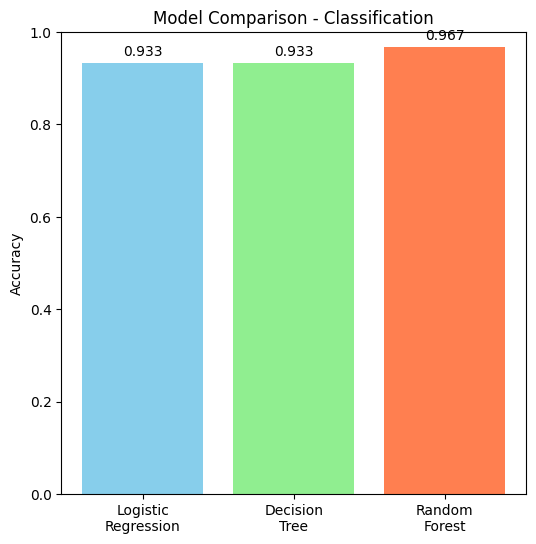

In [ ]:
# Visualization
plt.figure(figsize=(6, 6))


models = ['Logistic\nRegression', 'Decision\nTree', 'Random\nForest']
accuracies = [acc_log, acc_dt, acc_rf]
bars = plt.bar(models, accuracies, color=['skyblue', 'lightgreen', 'coral'])
plt.ylabel('Accuracy')
plt.title('Model Comparison - Classification')
plt.ylim([0, 1])
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{acc:.3f}', ha='center', va='bottom')




plt.show()

Text(0.5, 1.0, 'Feature Importance (Random Forest)')

<Figure size 400x200 with 0 Axes>

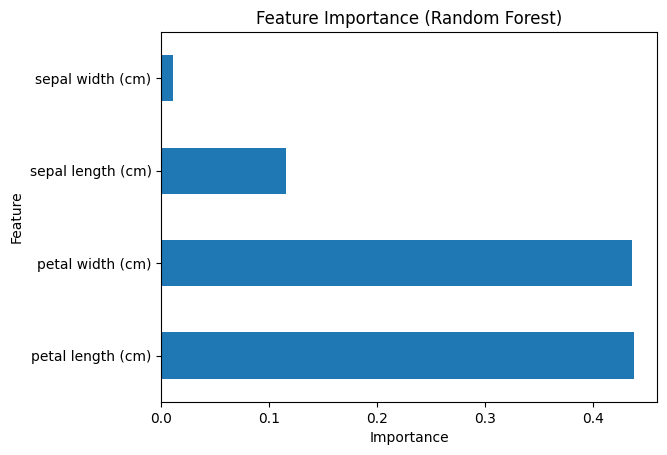

In [ ]:
plt.figure(figsize=(4, 2))
feature_importance.plot(x='Feature', y='Importance', kind='barh', legend=False)
plt.xlabel('Importance')
plt.title('Feature Importance (Random Forest)')

In [ ]:
from sklearn.cluster import KMeans
X_cluster = df_classification.iloc[:, :2].values

print(f"\n📊 Using features: {df_classification.columns[:2].tolist()}")
print(f"Data shape: {X_cluster.shape}")


📊 Using features: ['sepal length (cm)', 'sepal width (cm)']
Data shape: (150, 2)



------------------------------------------------------------
FINDING OPTIMAL NUMBER OF CLUSTERS (ELBOW METHOD)
------------------------------------------------------------

🔍 Look for the 'elbow' point where inertia starts decreasing slowly
Inertia values:
K=1: 130.48
K=2: 58.20
K=3: 37.05
K=4: 27.99
K=5: 21.00
K=6: 17.41
K=7: 14.83
K=8: 12.84
K=9: 11.24


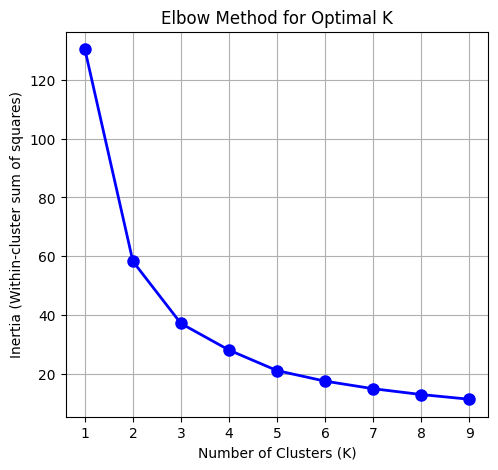

In [ ]:
print("\n" + "-"*60)
print("FINDING OPTIMAL NUMBER OF CLUSTERS (ELBOW METHOD)")
print("-"*60)

inertias = []
K_range = range(1, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_cluster)
    inertias.append(kmeans.inertia_)

# Plot elbow curve
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (Within-cluster sum of squares)')
plt.title('Elbow Method for Optimal K')
plt.grid(True)

print("\n🔍 Look for the 'elbow' point where inertia starts decreasing slowly")
print("Inertia values:")
for k, inertia in zip(K_range, inertias):
    print(f"K={k}: {inertia:.2f}")

In [ ]:
import numpy as np
optimal_k = 3
print(f"\n✅ Choosing K = {optimal_k} clusters")

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_cluster)

print(f"\n📊 Cluster Distribution:")
unique, counts = np.unique(clusters, return_counts=True)
for cluster, count in zip(unique, counts):
    print(f"Cluster {cluster}: {count} samples")



✅ Choosing K = 3 clusters

📊 Cluster Distribution:
Cluster 0: 47 samples
Cluster 1: 53 samples
Cluster 2: 50 samples


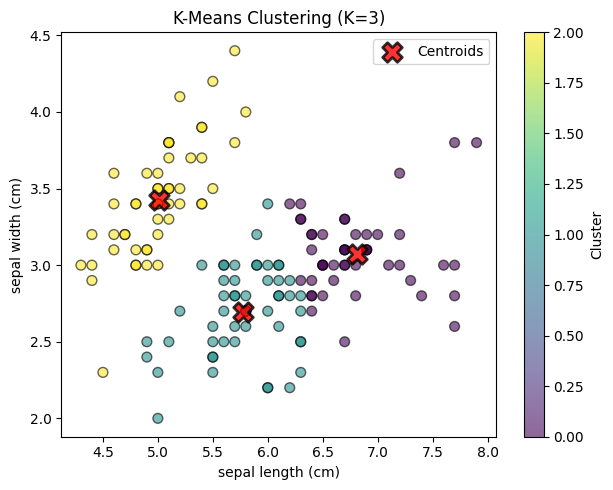

In [ ]:
# Visualize clusters
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 2)
scatter = plt.scatter(X_cluster[:, 0], X_cluster[:, 1], c=clusters,
                     cmap='viridis', s=50, alpha=0.6, edgecolors='black')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
           c='red', s=200, alpha=0.8, marker='X', edgecolors='black', linewidths=2,
           label='Centroids')
plt.xlabel(df_classification.columns[0])
plt.ylabel(df_classification.columns[1])
plt.title(f'K-Means Clustering (K={optimal_k})')
plt.legend()
plt.colorbar(scatter, label='Cluster')

plt.tight_layout()
plt.show()

In [ ]:
print("\n🔍 Comparing Clusters with Actual Species:")
comparison = pd.DataFrame({
    'Actual_Species': df_classification['species'],
    'Predicted_Cluster': clusters
})
# print("\nCross-tabulation:")
# print(pd.crosstab(comparison['Actual_Species'], comparison['Predicted_Cluster']))
comparison



🔍 Comparing Clusters with Actual Species:


,Actual_Species,Predicted_Cluster
0,0,2
1,0,2
2,0,2
3,0,2
4,0,2
...,...,...
145,2,0
146,2,1
147,2,0
148,2,0


# M


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_diabetes,load_iris
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,mean_squared_error,r2_score,mean_absolute_error
from sklearn.preprocessing import StandardScaler


In [ ]:
data = load_diabetes()
data.keys()

dict_keys(['data', 'target', 'frame', 'DESCR', 'feature_names', 'data_filename', 'target_filename', 'data_module'])

In [ ]:
data = load_diabetes()
data.keys()

df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [ ]:
df.columns

Index(['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6',
       'target'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  target  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB


<Axes: >

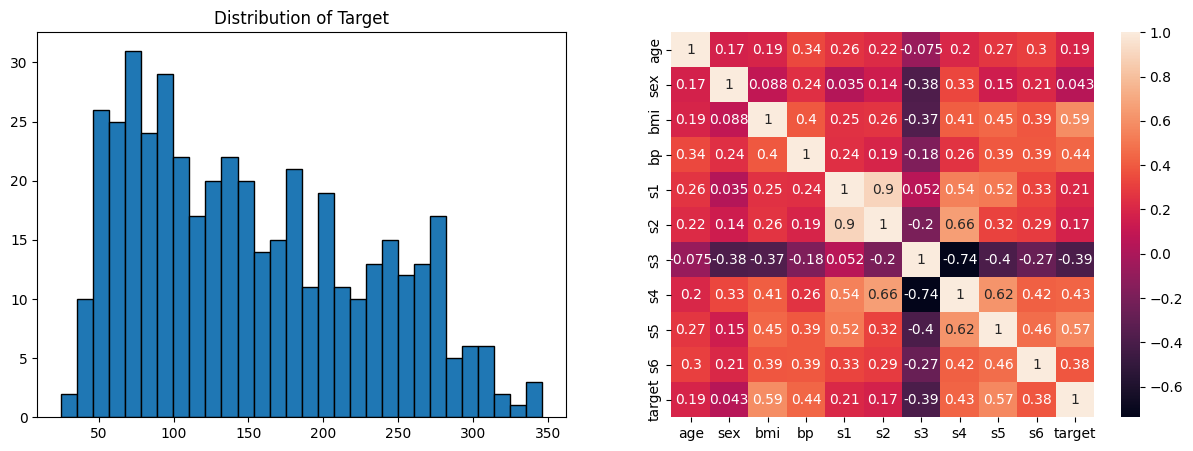

In [ ]:

plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.hist(df['target'], bins=30, edgecolor='black')
plt.title('Distribution of Target')

plt.subplot(1, 2, 2)
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True)

In [ ]:
Y = df['target']
X = df.drop(['target'],axis=1)

In [ ]:
X

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641
...,...,...,...,...,...,...,...,...,...,...
437,0.041708,0.050680,0.019662,0.059744,-0.005697,-0.002566,-0.028674,-0.002592,0.031193,0.007207
438,-0.005515,0.050680,-0.015906,-0.067642,0.049341,0.079165,-0.028674,0.034309,-0.018114,0.044485
439,0.041708,0.050680,-0.015906,0.017293,-0.037344,-0.013840,-0.024993,-0.011080,-0.046883,0.015491
440,-0.045472,-0.044642,0.039062,0.001215,0.016318,0.015283,-0.028674,0.026560,0.044529,-0.025930


In [ ]:
X_train,X_test,y_train,y_test = train_test_split(X,Y,test_size=0.2,shuffle=True,random_state=42)

In [ ]:
print(f"train_dataset shape : {X_train.shape[0]}")
print(f"test_dataset shape : {X_test.shape[0]}")

train_dataset shape : 353
test_dataset shape : 89


In [ ]:
lr = LinearRegression()
lr.fit(X_train,y_train)


LinearRegression()

In [ ]:
pred= lr.predict(X_test)

In [ ]:
pred[:5]

array([139.5475584 , 179.51720835, 134.03875572, 291.41702925,
       123.78965872])

In [ ]:
y_test[:5].values

array([219.,  70., 202., 230., 111.])

In [ ]:

print("R2 score : ",r2_score(y_test,pred))
print("MSE Error: ",mean_squared_error(y_test,pred))
print("MAE Error: ",mean_absolute_error(y_test,pred))

R2 score :  0.4526027629719195
MSE Error:  2900.193628493482
MAE Error:  42.79409467959994


In [ ]:
df_metrics = pd.DataFrame({'Actual':y_test,'Predicted':pred})



In [ ]:
df_metrics['error'] = df_metrics['Actual'] - df_metrics['Predicted']
df_metrics['Sq_error'] = df_metrics['error']**2
mse = sum(df_metrics['Sq_error'])/len(df_metrics)
# mae = sum(abs(df_metrics['error']))/len(df_metrics)
print("MSE : ",mse)
# print("MAE : ",mae)
df_metrics.head(10)

MSE :  2900.193628493482


,Actual,Predicted,error,Sq_error
287,219.0,139.547558,79.452442,6312.690476
211,70.0,179.517208,-109.517208,11994.018926
72,202.0,134.038756,67.961244,4618.730724
321,230.0,291.417029,-61.417029,3772.051482
73,111.0,123.789659,-12.789659,163.575370
418,84.0,92.172347,-8.172347,66.787247
367,242.0,258.232389,-16.232389,263.490452
354,272.0,181.337321,90.662679,8219.721441
281,94.0,90.224113,3.775887,14.257322
148,96.0,108.633759,-12.633759,159.611856


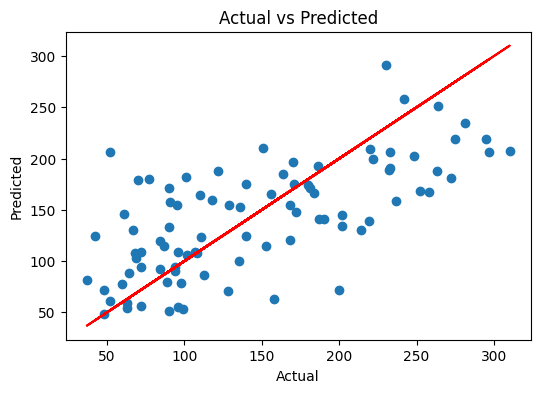

In [ ]:
plt.figure(figsize=(6,4))
plt.scatter(y_test,pred)
plt.plot(y_test,y_test,'r')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

In [ ]:
iris = load_iris()
df_iris = pd.DataFrame(iris.data, columns=iris.feature_names)
df_iris['species'] = iris.target
df_iris.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [ ]:
df_iris.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [ ]:
df_iris['species'].unique()

array([0, 1, 2])

In [ ]:
df_iris['species'].value_counts()

,count
species,
0,50
1,50
2,50


In [ ]:
X_iris = df_iris.drop('species', axis=1)
y_iris = df_iris['species']

In [ ]:
X_train_iris, X_test_iris, y_train_iris, y_test_iris = train_test_split(
    X_iris, y_iris, test_size=0.2, random_state=42, stratify=y_iris)

In [ ]:
dt = DecisionTreeClassifier(random_state=42,max_depth=4)
dt.fit(X_train_iris,y_train_iris)

DecisionTreeClassifier(max_depth=4, random_state=42)

In [ ]:
pred= dt.predict(X_test_iris)
print(f"Accuracy : {accuracy_score(y_test_iris,pred)}")

Accuracy : 0.9333333333333333


In [ ]:
print(classification_report(y_test_iris,pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.90      0.90      0.90        10
           2       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



In [ ]:
y_test_iris.shape

(30,)

<Axes: >

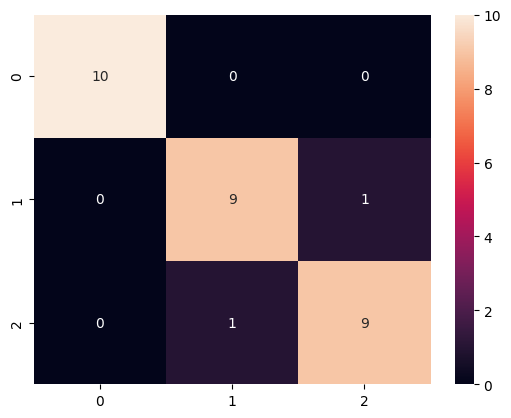

In [ ]:
cm  = confusion_matrix(y_test_iris,pred)
sns.heatmap(cm,annot=True)

In [ ]:
import joblib

filename = 'dt_model'
joblib.dump(dt, filename)

['dt_model']

In [ ]:
load_model = joblib.load(filename)

In [ ]:
load_model.predict(X_test_iris)

array([0, 2, 1, 1, 0, 1, 0, 0, 2, 1, 2, 2, 2, 1, 0, 0, 0, 1, 1, 2, 0, 2,
       1, 1, 2, 2, 1, 0, 2, 0])

In [ ]:
load_model.predict()

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
data = {
    "area":[10,20,30,40,50,60,70,80,90,100],
    "price":[300,400,500,600,700,800,900,1000,1100,1200]
}

data = pd.DataFrame(data)
data

,area,price
0,10,300
1,20,400
2,30,500
3,40,600
4,50,700
5,60,800
6,70,900
7,80,1000
8,90,1100
9,100,1200


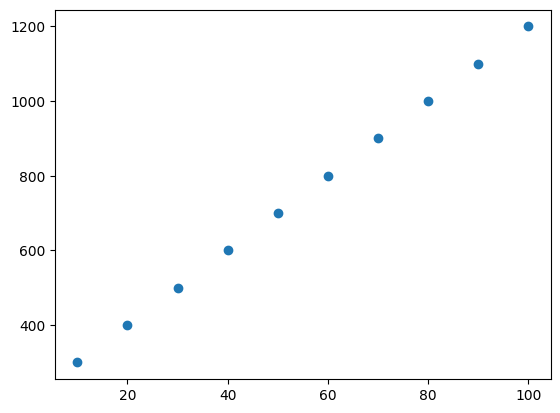

In [ ]:
plt.scatter(data['area'],data['price'])
plt.show()

In [ ]:
X = data['area']
y = data['price']




In [ ]:
import numpy as np

w = 10
b = 200
def lrr_compute(X_train,w,b):
  pred_matrix =np.zeros(X_train.shape[0])
  for i in range(X_train.shape[0]):
    pred_matrix[i] = w*X_train.iloc[i] + b

  return pred_matrix

In [ ]:
pred = lrr_compute(X,w,b)
pred

array([ 300.,  400.,  500.,  600.,  700.,  800.,  900., 1000., 1100.,
       1200.])

In [ ]:
mean_squared_error(y,pred)

0.0

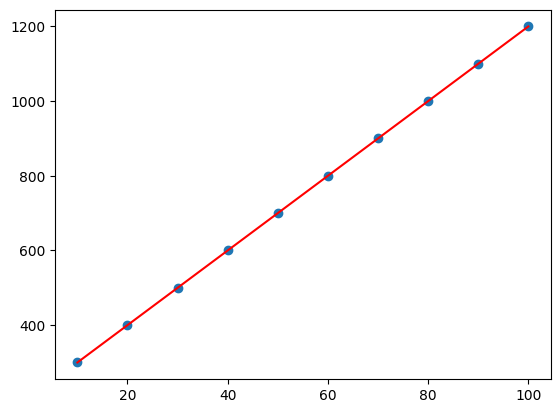

In [ ]:
plt.scatter(X,y)
plt.plot(X,pred,"r")
plt.show()

In [ ]:
lr  = LinearRegression()
lr

LinearRegression()

In [ ]:
X = data['area'].values.reshape(-1,1)
y = data['price']

In [ ]:
lr.fit(X,y)

LinearRegression()

In [ ]:
mean_squared_error(y,lr.predict(X))

0.0

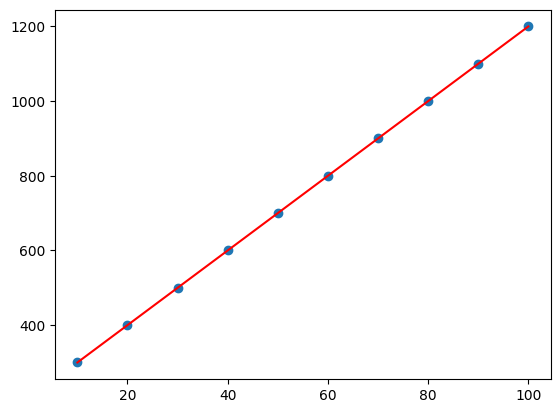

In [ ]:
plt.scatter(X,y)
plt.plot(X,lr.predict(X),"r")
plt.show()